In [16]:
pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model


# -------------------------------
# Load Image
# -------------------------------
def load_image(path, max_dim=512):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)

    shape = tf.shape(image)[:-1]
    long_dim = tf.reduce_max(shape)
    scale = max_dim / tf.cast(long_dim, tf.float32)

    new_shape = tf.cast(tf.cast(shape, tf.float32) * scale, tf.int32)
    image = tf.image.resize(image, new_shape)

    image = image[tf.newaxis, :]
    return image

In [18]:
# -------------------------------
# Show Image
# -------------------------------
def show_image(image, title=None):
    image = tf.squeeze(image)
    plt.imshow(image)

    if title:
        plt.title(title)

    plt.axis('off')
    plt.show()

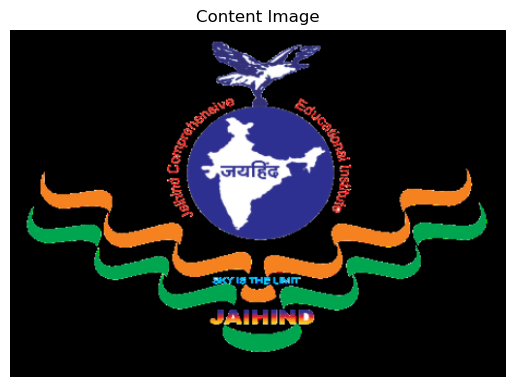

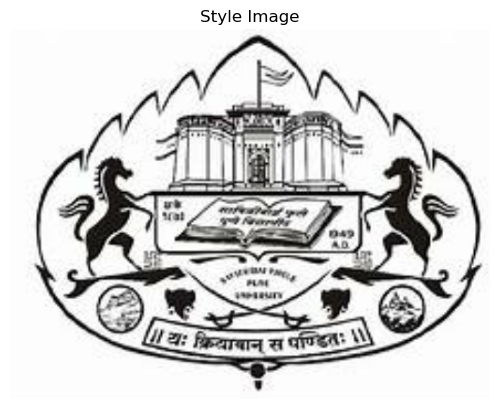

In [19]:
# -------------------------------
# Load Images
# -------------------------------
content_image = load_image("jcoelogo.png")
style_image = load_image("sppulogo.jpg")

show_image(content_image, "Content Image")
show_image(style_image, "Style Image")

In [20]:
# Load VGG Model
# -------------------------------
vgg = VGG19(include_top=False, weights='imagenet')
vgg.trainable = False


# -------------------------------
# Define Layers
# -------------------------------
content_layers = ['block5_conv2']

style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

outputs = [vgg.get_layer(name).output for name in (style_layers + content_layers)]
model = Model(vgg.input, outputs)

In [21]:
# -------------------------------
# Gram Matrix
# -------------------------------
def gram_matrix(input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)

    num_locations = tf.cast(
        tf.shape(input_tensor)[1] * tf.shape(input_tensor)[2],
        tf.float32
    )

    return result / num_locations
# -------------------------------
# Targets
# -------------------------------
style_outputs = model(style_image)[:num_style_layers]
content_outputs = model(content_image)[num_style_layers:]

style_targets = [gram_matrix(style) for style in style_outputs]
content_targets = content_outputs


In [22]:
# -------------------------------
# Loss Function
# -------------------------------
style_weight = 1e-2
content_weight = 1e4

def compute_loss(outputs):
    style_outputs = outputs[:num_style_layers]
    content_outputs = outputs[num_style_layers:]

    style_loss = tf.add_n([
        tf.reduce_mean((gram_matrix(style_outputs[i]) - style_targets[i])**2)
        for i in range(num_style_layers)
    ])

    content_loss = tf.add_n([
        tf.reduce_mean((content_outputs[i] - content_targets[i])**2)
        for i in range(num_content_layers)
    ])

    total_loss = style_weight * style_loss + content_weight * content_loss
    return total_loss

In [23]:
# -------------------------------
# Optimization
# -------------------------------
generated_image = tf.Variable(content_image)

optimizer = tf.optimizers.Adam(learning_rate=0.02)

epochs = 5
steps_per_epoch = 25

# -------------------------------
# Training Loop
# -------------------------------
for epoch in range(epochs):
    for step in range(steps_per_epoch):

        with tf.GradientTape() as tape:
            outputs = model(generated_image)
            loss = compute_loss(outputs)

        gradients = tape.gradient(loss, generated_image)
        optimizer.apply_gradients([(gradients, generated_image)])

        generated_image.assign(
            tf.clip_by_value(generated_image, 0.0, 1.0)
        )

    print(f"Epoch {epoch+1} completed")


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed


In [ ]:
# -------------------------------
# Show Final Output
# -------------------------------
show_image(generated_image, "Generated Image")